# Smart Route Optimization Simulation

A Python-based simulation project focused on route optimization and intelligent decision-making under changing conditions.

## Current Features
- Graph-based city modeling
- Weighted road networks
- Dijkstra shortest path algorithm
- Dynamic traffic simulation
- Route optimization analysis

## Future Improvements
- Route visualization
- Algorithm comparisons
- Reinforcement learning optimization

{'A': ['B', 'D'], 'B': ['A', 'C', 'E'], 'C': ['B', 'F'], 'D': ['A', 'E', 'G'], 'E': ['B', 'D', 'F', 'H'], 'F': ['C', 'E', 'I'], 'G': ['D', 'H'], 'H': ['G', 'E', 'I'], 'I': ['F', 'H']}

Normal Conditions:
Route: ['A', 'D', 'E', 'F', 'I']
Travel Time: 12 minutes

Traffic Conditions:
Route: ['A', 'B', 'E', 'F', 'I']
Travel Time: 16 minutes

--- Traffic Simulation Results ---

Simulation 1
Route: ['A', 'B', 'E', 'F', 'I']
Travel Time: 17 minutes

Simulation 2
Route: ['A', 'D', 'E', 'F', 'I']
Travel Time: 20 minutes

Simulation 3
Route: ['A', 'D', 'E', 'F', 'I']
Travel Time: 15 minutes

Simulation 4
Route: ['A', 'D', 'E', 'F', 'I']
Travel Time: 17 minutes

Simulation 5
Route: ['A', 'D', 'E', 'F', 'I']
Travel Time: 16 minutes

--- Simulation Analysis ---
Average Travel Time: 16.4 minutes
Best Travel Time: 12 minutes
Worst Travel Time: 20 minutes

--- Route Frequency Analysis ---
A → B → C → F → I selected 1 times
A → D → E → F → I selected 14 times
A → B → E → F → I selected 5 times


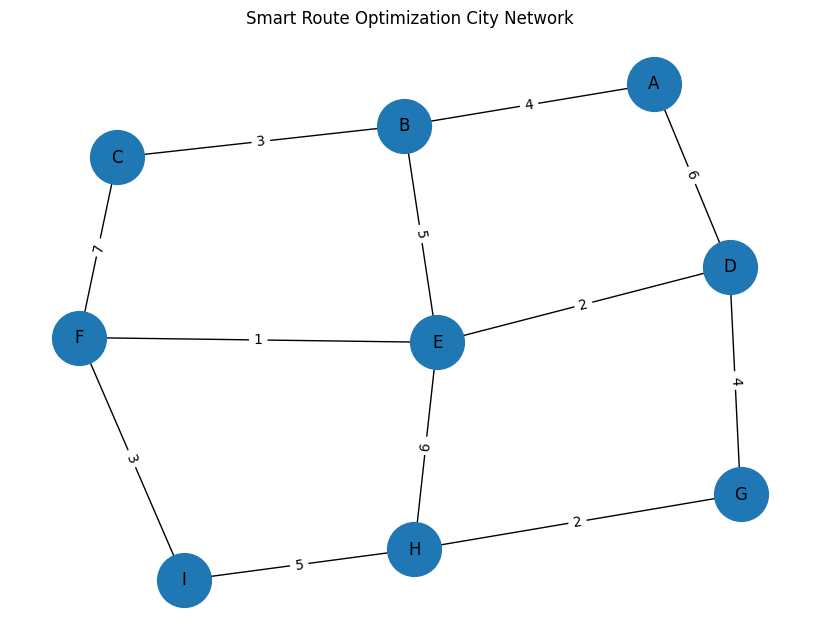

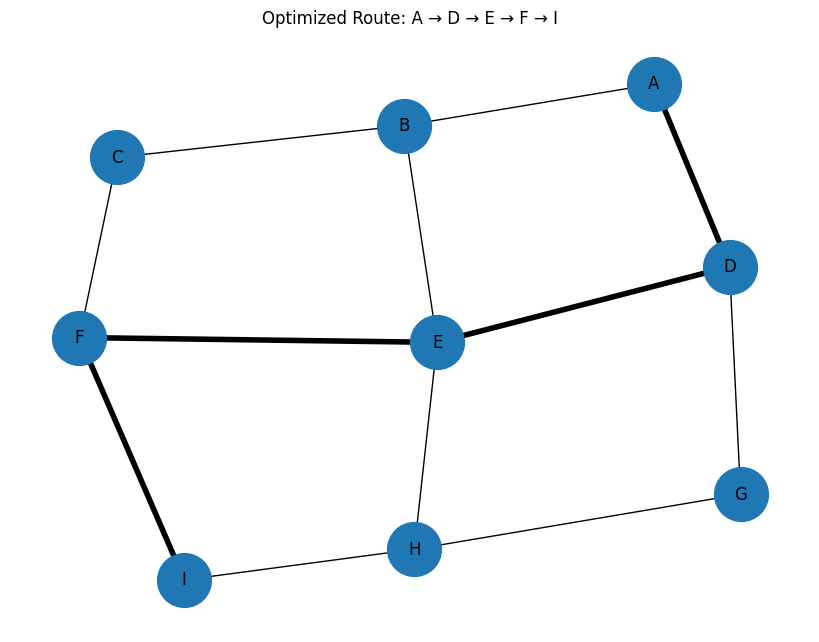

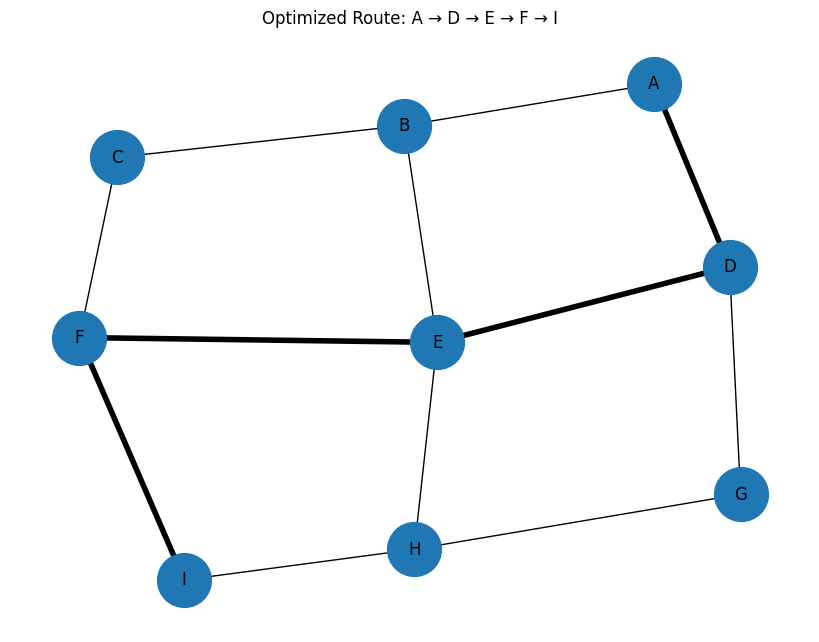

Traffic Route: ['A', 'D', 'E', 'F', 'I']
Travel Time: 18 minutes


In [15]:
# Smart Route Optimization Simulation
# Created by Cameron Frost


city = {
    "A": ["B", "D"],
    "B": ["A", "C", "E"],
    "C": ["B", "F"],
    "D": ["A", "E", "G"],
    "E": ["B", "D", "F", "H"],
    "F": ["C", "E", "I"],
    "G": ["D", "H"],
    "H": ["G", "E", "I"],
    "I": ["F", "H"]
}


print(city)



import heapq


roads = {
    ("A", "B"): 4,
    ("A", "D"): 6,
    ("B", "C"): 3,
    ("B", "E"): 5,
    ("C", "F"): 7,
    ("D", "E"): 2,
    ("D", "G"): 4,
    ("E", "F"): 1,
    ("E", "H"): 6,
    ("F", "I"): 3,
    ("G", "H"): 2,
    ("H", "I"): 5
}


def dijkstra(start, destination, road_conditions):

    distances = {}

    previous = {}

    for node in city:

        distances[node] = float("inf")

        previous[node] = None

    distances[start] = 0

    queue = [(0, start)]

    while queue:

        current_distance, current_node = heapq.heappop(queue)

        if current_node == destination:

            break

        for neighbor in city[current_node]:

            road = tuple(sorted([current_node, neighbor]))

            distance = road_conditions[road]

            new_distance = current_distance + distance

            if new_distance < distances[neighbor]:

                distances[neighbor] = new_distance

                previous[neighbor] = current_node

                heapq.heappush(queue, (new_distance, neighbor))

    path = []

    current = destination

    while current:

        path.append(current)

        current = previous[current]

    path.reverse()

    return path, distances[destination]

# -----------------------------------
# 6. Test Normal Conditions
# -----------------------------------

normal_route, normal_time = dijkstra("A", "I", roads)

print("\nNormal Conditions:")
print("Route:", normal_route)
print("Travel Time:", normal_time, "minutes")

# -----------------------------------
# Traffic Simulation Function
# -----------------------------------

import random

def update_traffic():

    traffic_roads = {}

    for road, time in roads.items():

        traffic_multiplier = random.uniform(0.8, 2.0)

        new_time = round(time * traffic_multiplier)

        traffic_roads[road] = new_time

    return traffic_roads


# -----------------------------------
# 7. Test Traffic Conditions
# -----------------------------------

traffic = update_traffic()

traffic_route, traffic_time = dijkstra("A", "I", traffic)

print("\nTraffic Conditions:")
print("Route:", traffic_route)
print("Travel Time:", traffic_time, "minutes")

# -----------------------------------
# 8. Run Multiple Traffic Simulations
# -----------------------------------

print("\n--- Traffic Simulation Results ---")

for simulation in range(1, 6):

    traffic = update_traffic()

    route, time = dijkstra("A", "I", traffic)

    print("\nSimulation", simulation)
    print("Route:", route)
    print("Travel Time:", time, "minutes")

# -----------------------------------
# 9. Analyze Simulation Results
# -----------------------------------

simulation_times = []

for simulation in range(1, 11):

    traffic = update_traffic()

    route, time = dijkstra("A", "I", traffic)

    simulation_times.append(time)


average_time = sum(simulation_times) / len(simulation_times)

best_time = min(simulation_times)

worst_time = max(simulation_times)


print("\n--- Simulation Analysis ---")
print("Average Travel Time:", round(average_time, 2), "minutes")
print("Best Travel Time:", best_time, "minutes")
print("Worst Travel Time:", worst_time, "minutes")

# -----------------------------------
# 10. Route Frequency Analysis
# -----------------------------------

route_history = []


for simulation in range(20):

    traffic = update_traffic()

    route, time = dijkstra("A", "I", traffic)

    route_history.append(" → ".join(route))


from collections import Counter


route_counts = Counter(route_history)


print("\n--- Route Frequency Analysis ---")

for route, count in route_counts.items():

    print(route, "selected", count, "times")

!pip install networkx matplotlib

import networkx as nx
import matplotlib.pyplot as plt

# -----------------------------------
# 11. Create City Network Visualization
# -----------------------------------

G = nx.Graph()


for node in city:
    G.add_node(node)


for road, distance in roads.items():
    G.add_edge(road[0], road[1], weight=distance)


plt.figure(figsize=(8,6))

position = nx.spring_layout(G, seed=42)


nx.draw(
    G,
    position,
    with_labels=True,
    node_size=1500,
    font_size=12
)


edge_labels = nx.get_edge_attributes(G, "weight")

nx.draw_networkx_edge_labels(
    G,
    position,
    edge_labels=edge_labels
)


plt.title("Smart Route Optimization City Network")

plt.show()

# -----------------------------------
# 12. Highlight Optimal Route
# -----------------------------------

def visualize_route(route):

    plt.figure(figsize=(8,6))

    position = nx.spring_layout(G, seed=42)


    # Draw entire network

    nx.draw(
        G,
        position,
        with_labels=True,
        node_size=1500,
        font_size=12
    )


    # Create route edges

    route_edges = []

    for i in range(len(route)-1):

        route_edges.append(
            (route[i], route[i+1])
        )


    # Highlight selected route

    nx.draw_networkx_edges(
        G,
        position,
        edgelist=route_edges,
        width=4
    )


    plt.title("Optimized Route: " + " → ".join(route))

    plt.show()

    normal_route, normal_time = dijkstra("A", "I", roads)

visualize_route(normal_route)

traffic = update_traffic()

traffic_route, traffic_time = dijkstra("A", "I", traffic)

visualize_route(traffic_route)

print("Traffic Route:", traffic_route)
print("Travel Time:", traffic_time, "minutes")
